In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve,auc
# Load dataset
df = pd.read_csv("C:/Users/Sudeshna Kalluri/Downloads/waterQuality1.csv")

In [63]:
df.head()

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [65]:
print(df["is_safe"].value_counts())

is_safe
0        7084
1         912
#NUM!       3
Name: count, dtype: int64


In [67]:
print("Dataset shape:", df.shape)
df.replace("?", np.nan, inplace=True)

print("Missing values before handling:")
print(df.isnull().sum())


Dataset shape: (7999, 21)
Missing values before handling:
aluminium      0
ammonia        0
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
is_safe        0
dtype: int64


In [69]:
# Remove duplicates
df = df.drop_duplicates()

# Convert numeric columns properly
df = df.apply(pd.to_numeric, errors='coerce')  # Non-numeric values become NaN

# Fill missing values with median
df = df.fillna(df.median())

# Features and target
X = df.drop("is_safe", axis=1)  # Replace with your target column name
y = df["is_safe"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

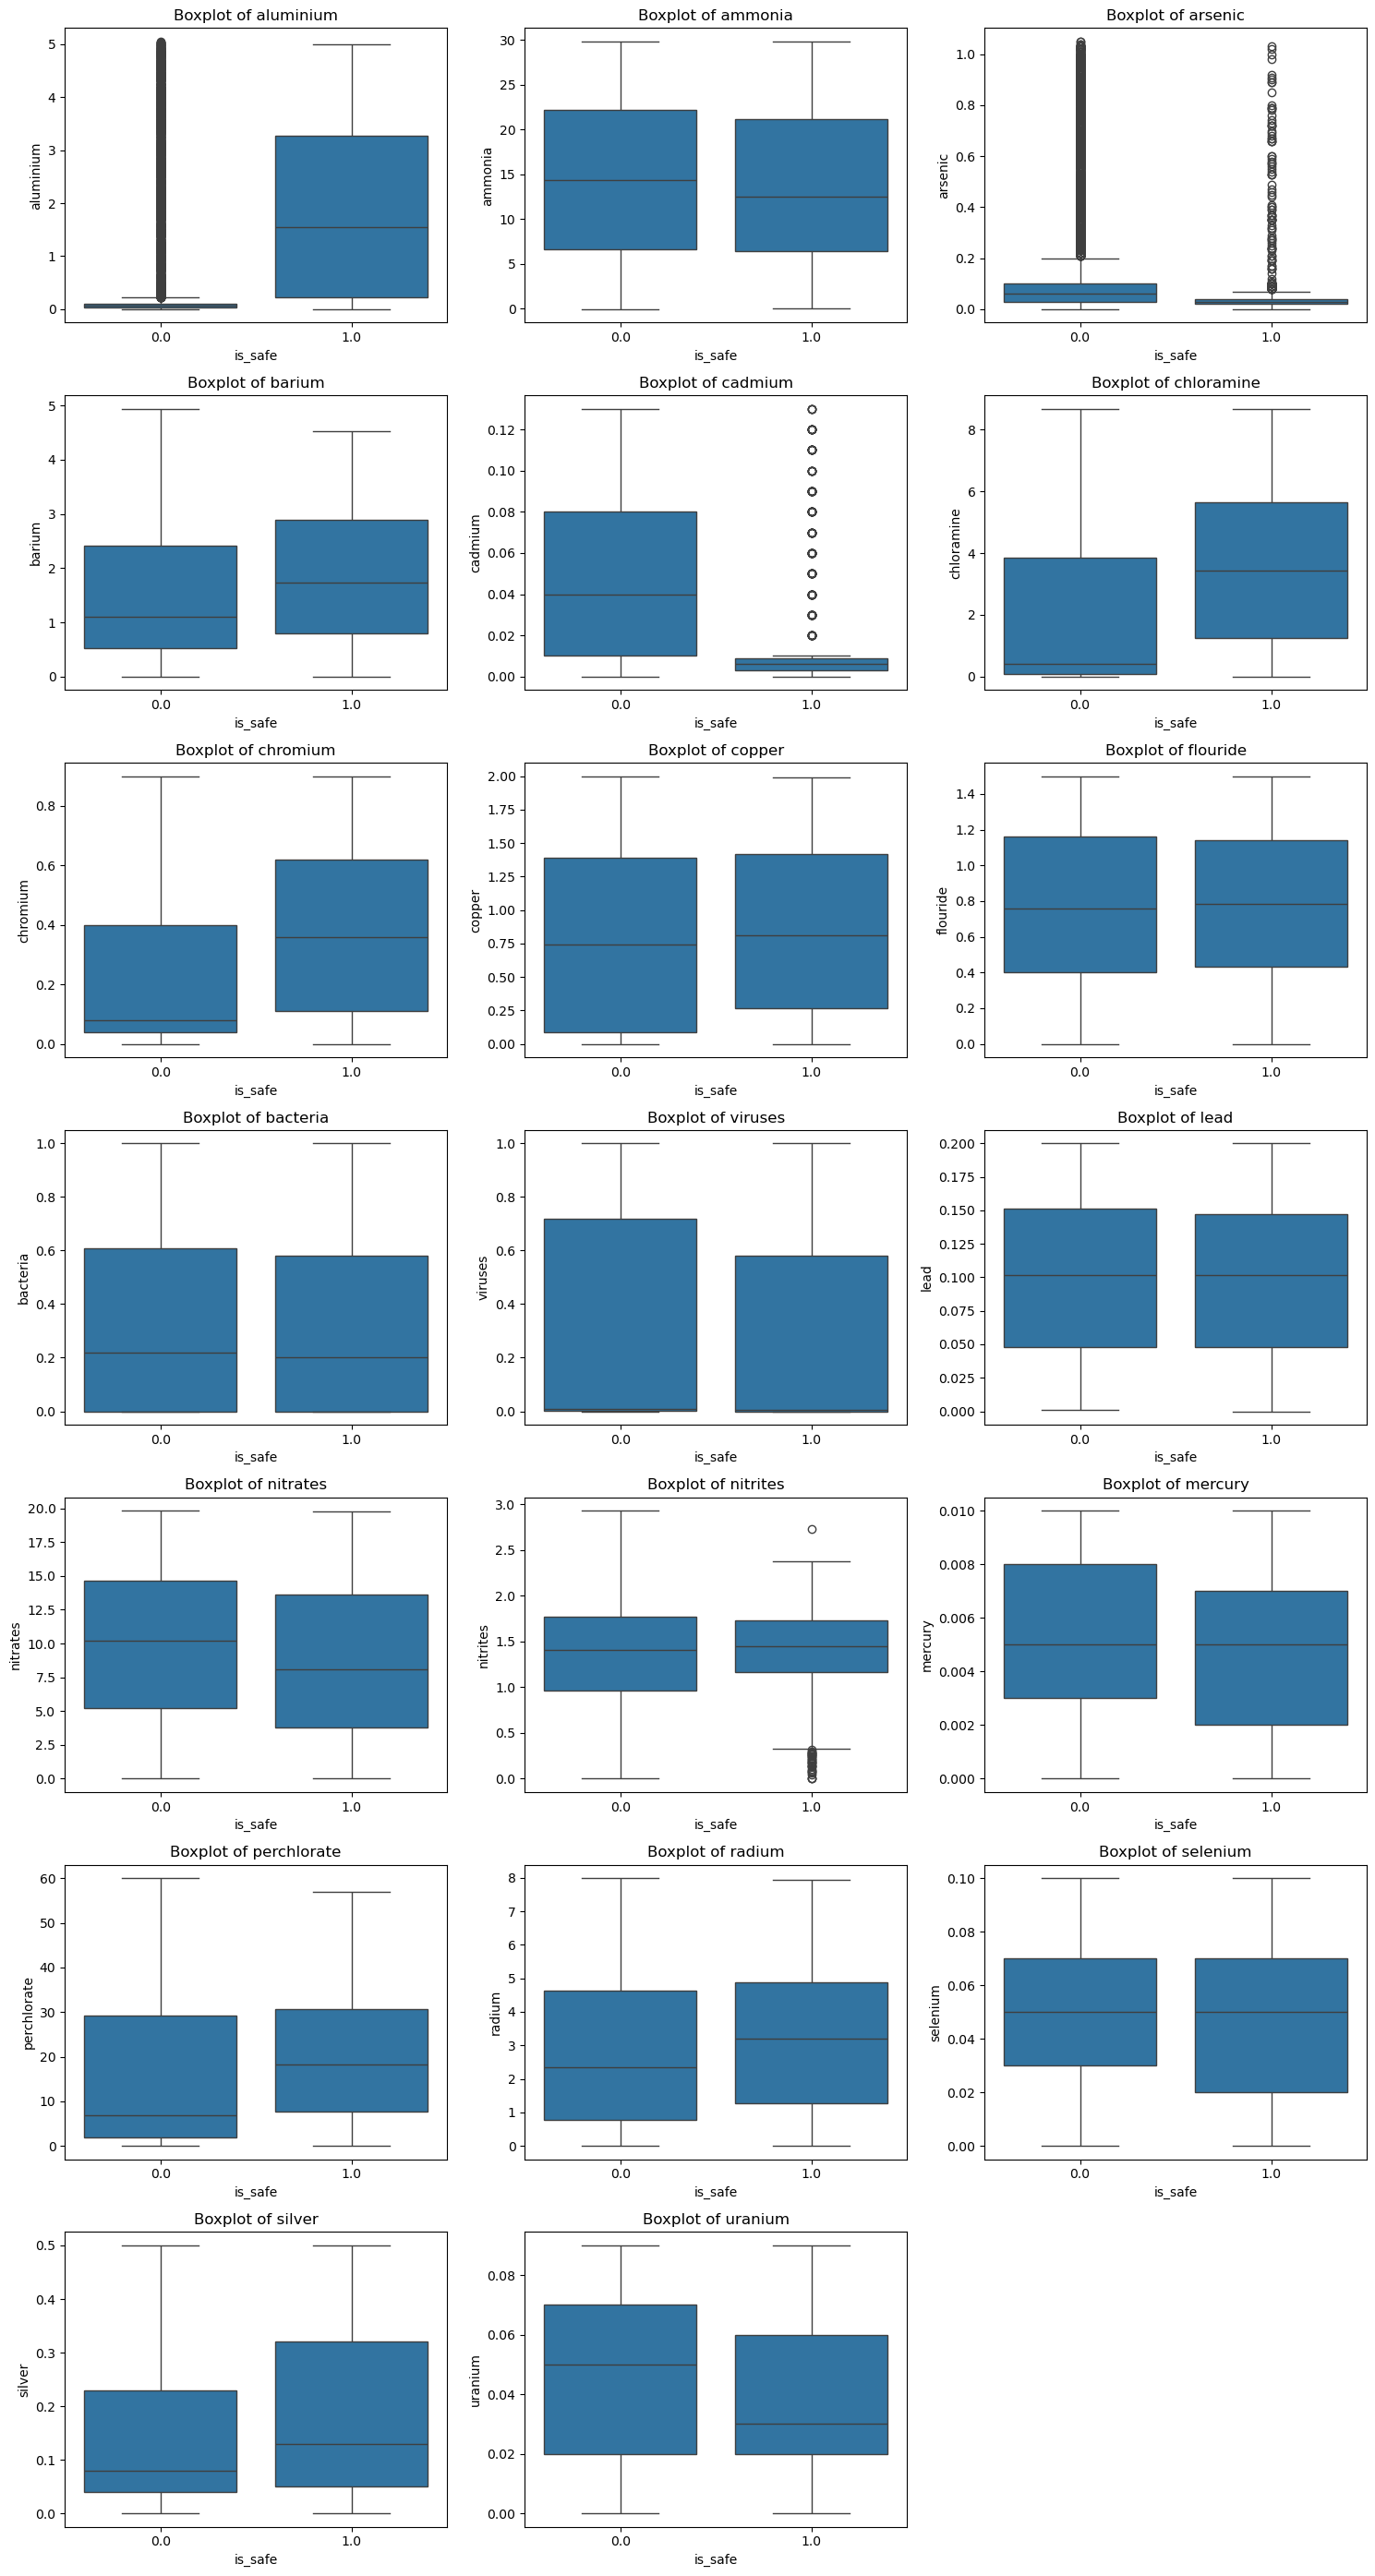

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

features = X.columns
n_features = len(features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))  # Make enough rows

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(data=df, x='is_safe', y=feature)
    plt.title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

## *SVM*

SVM Accuracy: 0.89875
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.94      1418
         1.0       0.53      0.85      0.66       182

    accuracy                           0.90      1600
   macro avg       0.76      0.88      0.80      1600
weighted avg       0.93      0.90      0.91      1600



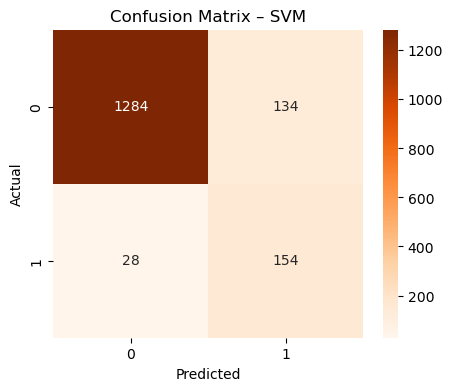

In [73]:
# ------------------------------
# Support Vector Machine
# ------------------------------
svm = SVC(kernel='rbf', probability=True, random_state=42, class_weight="balanced")
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", cmap='Oranges')
plt.title("Confusion Matrix – SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## *Logistic Regression*

Logistic Regression Accuracy: 0.801875
              precision    recall  f1-score   support

         0.0       0.96      0.81      0.88      1418
         1.0       0.33      0.73      0.45       182

    accuracy                           0.80      1600
   macro avg       0.64      0.77      0.67      1600
weighted avg       0.89      0.80      0.83      1600



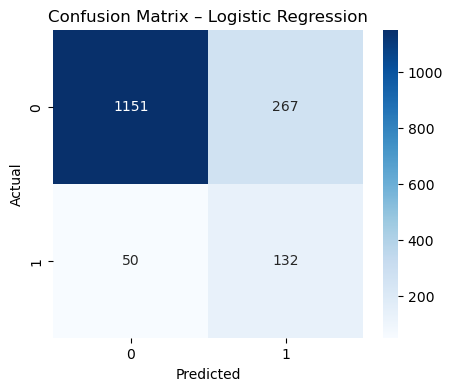

In [75]:
# ------------------------------
# Logistic Regression
# ------------------------------
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

 ## *K-Nearest Neighbors*

KNN Accuracy: 0.904375
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.95      1418
         1.0       0.63      0.38      0.48       182

    accuracy                           0.90      1600
   macro avg       0.78      0.68      0.71      1600
weighted avg       0.89      0.90      0.89      1600



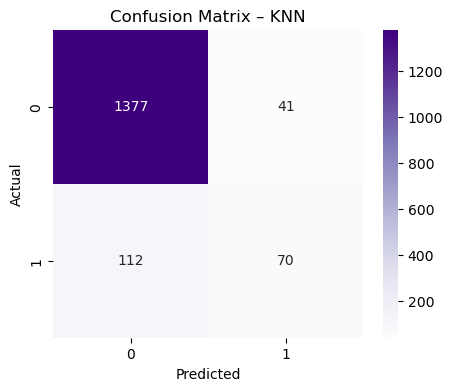

In [77]:
# ------------------------------
# K-Nearest Neighbors
# ------------------------------
knn = KNeighborsClassifier(n_neighbors=7, weights="distance")
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap='Purples')
plt.title("Confusion Matrix – KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## *Random forest*

Random Forest Accuracy: 0.96375
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      1418
         1.0       0.92      0.74      0.82       182

    accuracy                           0.96      1600
   macro avg       0.95      0.87      0.90      1600
weighted avg       0.96      0.96      0.96      1600



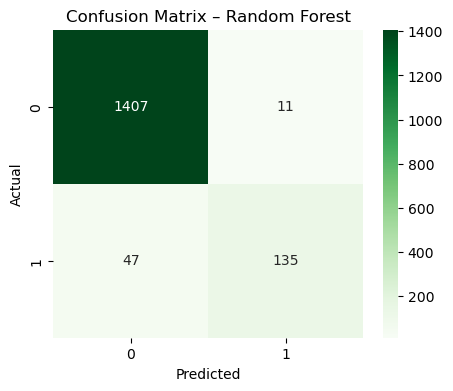

In [79]:
# ------------------------------
# Random Forest
# ------------------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, class_weight="balanced")
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap='Greens')
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


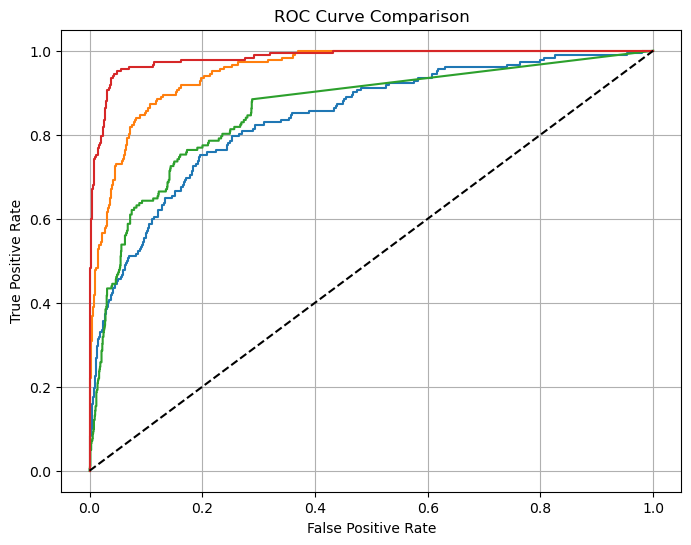

In [81]:
from sklearn.metrics import roc_curve, auc

# ------------------------------
# ROC Curves Comparison
# ------------------------------
plt.figure(figsize=(8,6))

roc_info = {
    "Logistic Regression": lr.predict_proba(X_test_scaled)[:,1],
    "SVM": svm.predict_proba(X_test_scaled)[:,1],
    "KNN": knn.predict_proba(X_test_scaled)[:,1],
    "Random Forest": rf.predict_proba(X_test_scaled)[:,1]
}

for name, y_prob in roc_info.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()